[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sanjaynagi/anopheles-omics-training/blob/main/day-1/1-3-workflow-managers.ipynb)

# 1.3 Workflow managers and Snakemake

**Theme:** Tools & technology

The Busia RNA-seq study has 16 sequencing runs. For each one we need quality control, read
trimming, quantification with kallisto and variant calling, followed by differential expression,
Fst, karyotyping and more across all samples. That is hundreds of jobs. Running them by hand, or
with a long bash script, is slow and error-prone, and it leaves a poor record of what was done.

Workflow managers solve this. In the next module you launch **RNA-Seq-Pop**, a Snakemake workflow,
on the Busia data, and on Day 4 you run **AmpSeeker**, another one. This module explains what a
workflow manager does, teaches the Snakemake concepts you need to configure and debug those
workflows, and lets you build and run a small workflow yourself. It ends with a comparison with
Nextflow, the other widely used workflow manager.

## Learning objectives

At the end of this module you will be able to:

- Explain four benefits of workflow managers: reproducibility, scalability, resumability and provenance.
- Describe the main Snakemake concepts: rules, inputs and outputs, wildcards, the DAG, config files and `conda:` environments.
- Write, dry-run and run a small Snakemake workflow, and view its DAG.
- Compare Snakemake and Nextflow and recognise the structure of a Nextflow pipeline.

## Setup

In Colab we install a pinned version of Snakemake. Colab normally has Graphviz (the `dot`
program, used to draw the workflow graph) already; the cell installs it if not. On Codespaces
or your own computer, use the course's pixi environment instead (`pixi run lab` from the
repository root), which includes Snakemake 9.27.0 and Graphviz.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q --no-warn-conflicts snakemake==9.27.0
    !which dot > /dev/null || apt-get -qq install -y graphviz > /dev/null

In [2]:
import os
import random
import subprocess
from pathlib import Path

import pandas as pd
from IPython.display import SVG, display

# Build the toy workflow in course-work/toy-workflow (stay put if this cell is run twice)
WORKDIR = Path.cwd() if Path.cwd().name == "toy-workflow" else Path("course-work/toy-workflow").resolve()
WORKDIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)
print("Working in", WORKDIR)

Working in /content/course-work/toy-workflow


In [3]:
!snakemake --version

9.27.0


## Why use a workflow manager?

| Benefit | What it means | Example from this course |
|---|---|---|
| **Reproducibility** | The whole analysis is written down as code, with the software environment for each step. Anyone can rerun it and get the same results | The RNA-Seq-Pop paper's results can be regenerated from the workflow and its config |
| **Scalability** | The same workflow runs on a laptop, a server, an HPC cluster or the cloud. Independent jobs run in parallel | Busia mini data on Codespaces; the full ~113 GB dataset on HPC, with no code changes |
| **Resumability** | Only missing or out-of-date outputs are rebuilt. If a job fails at step 9, steps 1–8 are not repeated | Add a sample, and only that sample's jobs (plus the combined steps) run |
| **Provenance** | Logs, parameters and software versions are recorded for every output; reports can be generated automatically | RNA-Seq-Pop and AmpSeeker produce results books you will explore on Days 2 and 4 |

A bash script gives you some of the first point and none of the others.

## Snakemake concepts

Snakemake [1, 2] describes a workflow as a set of **rules**, written in a Python-based language.
Its design follows the old Unix tool `make`: you ask for the files you want, and Snakemake works
out which rules to run to create them.

### Rules, inputs and outputs

A rule says how to make output files from input files:

```python
rule count_reads:
    input:
        "data/BusRes_1.fastq"
    output:
        "results/counts/BusRes_1.txt"
    shell:
        "echo $(( $(wc -l < {input}) / 4 )) > {output}"
```

The command can be a `shell:` command, a Python `run:` block, or a separate script (`script:`).
Rules can also have `params:`, `threads:`, `log:` and `benchmark:` sections.

### Wildcards

Writing one rule per sample would be tedious. **Wildcards** turn a rule into a template:

```python
rule count_reads:
    input:
        "data/{sample}.fastq"
    output:
        "results/counts/{sample}.txt"
    shell:
        "echo $(( $(wc -l < {input}) / 4 )) > {output}"
```

If you ask for `results/counts/Kis_1.txt`, Snakemake matches it against the output pattern, sets
`sample=Kis_1`, and so knows it needs `data/Kis_1.fastq`.

### Targets and `expand()`

By convention the first rule, `all`, lists the final files you want. `expand()` fills in a
pattern for every value in a list:

```python
SAMPLES = ["Kis_1", "BusSus_1", "BusRes_1"]

rule all:
    input:
        expand("results/counts/{sample}.txt", sample=SAMPLES)
```

### The DAG

Starting from the targets, Snakemake works backwards through the rules and builds a
**directed acyclic graph (DAG)** of jobs: one job per rule per set of wildcard values. The DAG
shows which jobs depend on which, and which can run in parallel.

### Running

| Command | What it does |
|---|---|
| `snakemake -n` | **Dry run**: show which jobs would run, and why, without running them. Always do this first |
| `snakemake --cores 4` | Run, with up to 4 jobs (or threads) at once |
| `snakemake --dag \| dot -Tsvg > dag.svg` | Draw the DAG |
| `snakemake --sdm conda --cores 4` | Build and use a separate conda environment for each rule that has a `conda:` directive (older versions: `--use-conda`) |
| `snakemake --report report.html` | After a run, build an HTML report with results, runtimes, code and software versions |

### Config files

Sample names and parameters should not be written into the Snakefile. They go in a config file
(YAML), so the same workflow can be reused on new data:

```python
configfile: "config/config.yaml"
SAMPLES = config["samples"]
```

RNA-Seq-Pop uses exactly this pattern: a `config/config.yaml` for settings and contrasts, and a
`config/samples.tsv` sample sheet. Module 1.4 walks through them.

### Software environments per rule

Each rule can have its own conda environment file, so tools with conflicting dependencies can
sit in one workflow, and the software versions are recorded with the code:

```python
rule kallisto_quant:
    input:
        index="resources/transcriptome.idx",
        r1="data/{sample}_1.fastq.gz",
        r2="data/{sample}_2.fastq.gz",
    output:
        directory("results/quant/{sample}"),
    log:
        "logs/kallisto/{sample}.log",
    threads: 4
    conda:
        "envs/kallisto.yaml"   # relative to the Snakefile
    shell:
        "kallisto quant -i {input.index} -o {output} -t {threads} "
        "{input.r1} {input.r2} 2> {log}"
```

where `workflow/envs/kallisto.yaml` is a normal, pinned conda environment file (Module 1.2).
This is why workflows still use conda even though we recommend pixi for projects: pixi installs
Snakemake, and Snakemake builds one conda environment per rule. Colab does
not support conda easily, so the toy workflow below uses only Python and shell.

### Standard layout

```text
my-workflow/
├── config/
│   ├── config.yaml
│   └── samples.tsv
├── workflow/
│   ├── Snakefile
│   ├── rules/          # rules split into files, pulled in with `include:`
│   ├── envs/           # conda environment files
│   └── scripts/
├── resources/          # reference files (genome, annotation)
└── results/
```

## Practical: a three-rule workflow

We build a small workflow on simulated reads for six samples named after the Busia study
groups (two each for Kisumu, Busia susceptible and Busia resistant). For each sample it counts the
reads and computes the GC content, then combines everything into one table.

### Step 1: make some toy data

The reads are random, so do not read anything biological into the numbers.

In [4]:
def make_fastq(path, n_reads, gc, read_len=50, seed=0):
    """Write a small FASTQ file with random reads of a given GC content."""
    rng = random.Random(seed)
    with open(path, "w") as f:
        for i in range(n_reads):
            seq = "".join(
                rng.choice("GC") if rng.random() < gc else rng.choice("AT")
                for _ in range(read_len)
            )
            f.write(f"@{Path(path).stem}_{i}\n{seq}\n+\n{'I' * read_len}\n")


samples = {  # sample: (number of reads, GC content)
    "Kis_1": (400, 0.44), "Kis_2": (350, 0.45),
    "BusSus_1": (500, 0.46), "BusSus_2": (450, 0.44),
    "BusRes_1": (300, 0.47), "BusRes_2": (550, 0.45),
}
Path("data").mkdir(exist_ok=True)
for i, (sample, (n, gc)) in enumerate(samples.items()):
    make_fastq(f"data/{sample}.fastq", n, gc, seed=i)

print(sorted(os.listdir("data")))
print(open("data/Kis_1.fastq").read()[:220])

['BusRes_1.fastq', 'BusRes_2.fastq', 'BusSus_1.fastq', 'BusSus_2.fastq', 'Kis_1.fastq', 'Kis_2.fastq']
@Kis_1_0
TCCTATGTAGTACATTGCATCAGGTCTCTATTGGATAAATTATTTGTACG
+
IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
@Kis_1_1
GGGAGGACAGGTGAAACGCGTCTAAAATATATTTTGAGACCATAGACCCA
+
IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII


### Step 2: the config file

We use `%%writefile` to write files from the notebook. In a real project you would edit them in
a text editor.

In [5]:
Path("config").mkdir(exist_ok=True)
Path("workflow").mkdir(exist_ok=True)

In [6]:
%%writefile config/config.yaml
samples:
  - Kis_1
  - Kis_2
  - BusSus_1
  - BusSus_2
  - BusRes_1
  - BusRes_2

Writing config/config.yaml


### Step 3: the Snakefile

Three rules do the work (`count_reads`, `gc_content`, `summarise`), and `all` names the final target.
Notice that `count_reads` uses a shell command, while the other two use Python `run:` blocks.
In a shell command, curly braces are Snakemake placeholders, so literal braces must be doubled.

In [7]:
%%writefile workflow/Snakefile
configfile: "config/config.yaml"

SAMPLES = config["samples"]


rule all:
    input:
        "results/summary.tsv",


rule count_reads:
    input:
        "data/{sample}.fastq",
    output:
        "results/counts/{sample}.txt",
    shell:
        "echo $(( $(wc -l < {input}) / 4 )) > {output}"


rule gc_content:
    input:
        "data/{sample}.fastq",
    output:
        "results/gc/{sample}.txt",
    run:
        gc = total = 0
        with open(input[0]) as f:
            for i, line in enumerate(f):
                if i % 4 == 1:  # the sequence line of each FASTQ record
                    seq = line.strip()
                    gc += seq.count("G") + seq.count("C")
                    total += len(seq)
        with open(output[0], "w") as out:
            out.write(f"{gc / total:.4f}\n")


rule summarise:
    input:
        counts=expand("results/counts/{sample}.txt", sample=SAMPLES),
        gc=expand("results/gc/{sample}.txt", sample=SAMPLES),
    output:
        "results/summary.tsv",
    run:
        with open(output[0], "w") as out:
            out.write("sample\tn_reads\tgc\n")
            for sample, counts, gc in zip(SAMPLES, input.counts, input.gc):
                n = open(counts).read().strip()
                g = open(gc).read().strip()
                out.write(f"{sample}\t{n}\t{g}\n")

Writing workflow/Snakefile


### Step 4: dry run

Snakemake finds `workflow/Snakefile` on its own. The dry run lists every job it would run and the
reason (here, missing output files). Nothing is created yet. `--quiet host` hides a block of
information about your computer that Snakemake prints first.

In [8]:
!snakemake -n --quiet host

Assuming unrestricted shared filesystem usage.
Building DAG of jobs...
Job stats:
job            count
-----------  -------
count_reads        6
gc_content         6
summarise          1
all                1
total             14


[Sat Sep 26 10:48:39 2026]
rule gc_content:
    input: data/Kis_1.fastq
    output: results/gc/Kis_1.txt
    jobid: 8
    reason: Missing output files: results/gc/Kis_1.txt
    wildcards: sample=Kis_1
    resources: tmpdir=/tmp
[Sat Sep 26 10:48:39 2026]
rule count_reads:
    input: data/Kis_2.fastq
    output: results/counts/Kis_2.txt
    jobid: 3
    reason: Missing output files: results/counts/Kis_2.txt
    wildcards: sample=Kis_2
    resources: tmpdir=/tmp
[Sat Sep 26 10:48:39 2026]
rule gc_content:
    input: data/BusSus_1.fastq
    output: results/gc/BusSus_1.txt
    jobid: 10
    reason: Missing output files: results/gc/BusSus_1.txt
    wildcards: sample=BusSus_1
    resources: tmpdir=/tmp
[Sat Sep 26 10:48:39 2026]
rule count_reads:
    input: data/Bu

### Step 5: draw the DAG

`--dag` prints the graph in Graphviz's `dot` language, and `dot` turns it into an image.
Each box is a job; the two per-sample rules can run in parallel, and `summarise` waits for all of them.

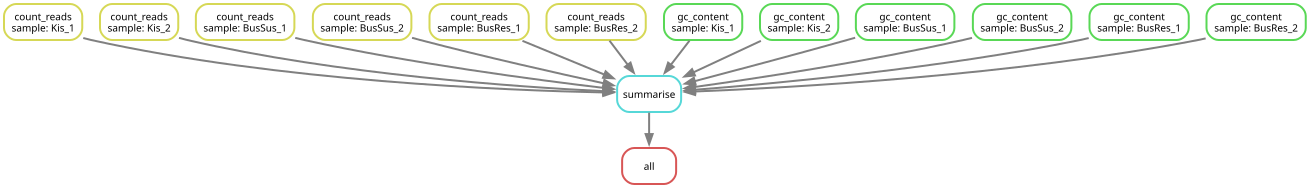

In [9]:
dag = subprocess.run("snakemake --dag | dot -Tsvg", shell=True, capture_output=True, text=True)
if dag.stdout.strip():
    display(SVG(dag.stdout))
else:  # e.g. Graphviz is not installed
    print(dag.stderr)

### Step 6: run it

This time we also hide the per-job details (`--quiet host rules`), leaving the progress messages.

In [10]:
!snakemake --cores 2 --quiet host rules

Assuming unrestricted shared filesystem usage.
Building DAG of jobs...
Using shell: /bin/bash
Provided cores: 2
Rules claiming more threads will be scaled down.
Job stats:
job            count
-----------  -------
count_reads        6
gc_content         6
summarise          1
all                1
total             14

Select jobs to execute...
Execute 2 jobs...
[Sat Sep 26 10:48:40 2026]
Finished jobid: 3 (Rule: count_reads)
1 of 14 steps (7%) done
Select jobs to execute...
Execute 1 jobs...
Select jobs to execute...
[Sat Sep 26 10:48:42 2026]
Finished jobid: 8 (Rule: gc_content)
2 of 14 steps (14%) done
Execute 1 jobs...
[Sat Sep 26 10:48:42 2026]
Finished jobid: 12 (Rule: gc_content)
3 of 14 steps (21%) done
Select jobs to execute...
Execute 1 jobs...
Select jobs to execute...
[Sat Sep 26 10:48:43 2026]
Finished jobid: 13 (Rule: gc_content)
4 of 14 steps (29%) done
[Sat Sep 26 10:48:43 2026]
Finished jobid: 11 (Rule: gc_content)
5 of 14 steps (36%) done
Execute 2 jobs...
Select jobs 

In [11]:
pd.read_csv("results/summary.tsv", sep="\t")

,sample,n_reads,gc
0,Kis_1,400,0.4377
1,Kis_2,350,0.4567
2,BusSus_1,500,0.4640
3,BusSus_2,450,0.4432
4,BusRes_1,300,0.4698
5,BusRes_2,550,0.4505


### Step 7: resumability

Run it again. Everything is up to date, so nothing runs.

In [12]:
!snakemake --cores 2 --quiet host rules

Assuming unrestricted shared filesystem usage.
Building DAG of jobs...
Nothing to be done (all requested files are present and up to date).


Now pretend that the sequencing provider re-delivered the data for one sample, with more reads.
The dry run shows that only the jobs downstream of that file will be rerun. With 16 real RNA-seq
samples, this saves hours.

In [13]:
make_fastq("data/BusRes_1.fastq", 320, 0.47, seed=42)
!snakemake -n --quiet host rules

Assuming unrestricted shared filesystem usage.
Building DAG of jobs...
Job stats:
job            count
-----------  -------
count_reads        1
gc_content         1
summarise          1
all                1
total              4

Job stats:
job            count
-----------  -------
count_reads        1
gc_content         1
summarise          1
all                1
total              4

Reasons:
    (check individual jobs above for details)
    input files updated by another job:
        all, summarise
    updated input files:
        count_reads, gc_content
This was a dry-run (flag -n). The order of jobs does not reflect the order of execution.


In [14]:
!snakemake --cores 2 --quiet host rules
pd.read_csv("results/summary.tsv", sep="\t")

Assuming unrestricted shared filesystem usage.
Building DAG of jobs...
Using shell: /bin/bash
Provided cores: 2
Rules claiming more threads will be scaled down.
Job stats:
job            count
-----------  -------
count_reads        1
gc_content         1
summarise          1
all                1
total              4

Select jobs to execute...
Execute 2 jobs...
[Sat Sep 26 10:48:50 2026]
Finished jobid: 6 (Rule: count_reads)
1 of 4 steps (25%) done
[Sat Sep 26 10:48:51 2026]
Finished jobid: 12 (Rule: gc_content)
2 of 4 steps (50%) done
Select jobs to execute...
Execute 1 jobs...
[Sat Sep 26 10:48:53 2026]
Finished jobid: 1 (Rule: summarise)
3 of 4 steps (75%) done
Select jobs to execute...
Execute 1 jobs...
[Sat Sep 26 10:48:53 2026]
Finished jobid: 0 (Rule: all)
4 of 4 steps (100%) done
Complete log(s): /content/course-work/toy-workflow/.snakemake/log/2026-09-26T104850.126699.snakemake.log
Elapsed time: 0:00:03.091470


,sample,n_reads,gc
0,Kis_1,400,0.4377
1,Kis_2,350,0.4567
2,BusSus_1,500,0.4640
3,BusSus_2,450,0.4432
4,BusRes_1,320,0.4729
5,BusRes_2,550,0.4505


Snakemake decides what to rerun from file modification times, and also from changes to the
rule's code, parameters, input file list and software environment. Recent versions also compare
the contents of small files, so updating a file's timestamp with `touch` is not always enough to
trigger a rerun. To force a rule to run again, use `--forcerun <rule>`.

## Exercises

### Exercise 1

Add a seventh sample, `BusRes_3`, with 250 reads and GC content 0.46. Create its FASTQ with
`make_fastq()`, add it to the config file, then do a dry run. Which jobs will run, and why
does `summarise` run again?

<details><summary>Show answer</summary>

```python
make_fastq("data/BusRes_3.fastq", 250, 0.46, seed=7)
with open("config/config.yaml", "a") as f:
    f.write("  - BusRes_3\n")
!snakemake -n --quiet host rules
```

Three jobs run: `count_reads` and `gc_content` for `BusRes_3` (their outputs do not exist yet),
and `summarise`, because its list of inputs has changed. Run it with `!snakemake --cores 2`.
The other samples are not touched.

</details>

### Exercise 2

Before running anything, predict what will happen if you delete `results/gc/BusSus_1.txt` and
do a dry run. Then check.

<details><summary>Show answer</summary>

```python
!rm results/gc/BusSus_1.txt
!snakemake -n --quiet host rules
```

Two jobs: `gc_content` for `BusSus_1` (missing output) and `summarise` (one of its inputs will
be newer than its output). Nothing else runs.

</details>

### Exercise 3

*(Stretch)* Add a rule `mean_length` that writes the mean read length of each sample to
`results/length/{sample}.txt`, and add it as a column in `summary.tsv`. Dry-run, run, and redraw
the DAG.

<details><summary>Show answer</summary>

Add this rule to `workflow/Snakefile`:

```python
rule mean_length:
    input:
        "data/{sample}.fastq",
    output:
        "results/length/{sample}.txt",
    shell:
        "awk 'NR % 4 == 2 {{ n++; total += length($0) }} END {{ print total / n }}' {input} > {output}"
```

(Note the doubled braces for awk.) Then change `summarise`:

```python
rule summarise:
    input:
        counts=expand("results/counts/{sample}.txt", sample=SAMPLES),
        gc=expand("results/gc/{sample}.txt", sample=SAMPLES),
        length=expand("results/length/{sample}.txt", sample=SAMPLES),
    output:
        "results/summary.tsv",
    run:
        with open(output[0], "w") as out:
            out.write("sample\tn_reads\tgc\tmean_length\n")
            for sample, counts, gc, length in zip(SAMPLES, input.counts, input.gc, input.length):
                n = open(counts).read().strip()
                g = open(gc).read().strip()
                l = open(length).read().strip()
                out.write(f"{sample}\t{n}\t{g}\t{l}\n")
```

Because the code of `summarise` changed, Snakemake reruns it (a "code changed" rerun trigger),
and runs `mean_length` for every sample.

</details>

## Nextflow, compared

Nextflow [3] is the other widely used bioinformatics workflow manager. You will not run it in
this course, but you will meet it, especially through **nf-core** [4], a community collection of
peer-reviewed pipelines (for example `nf-core/rnaseq`).

### Concepts

- A **process** is like a Snakemake rule: it declares inputs, outputs and a script.
- **Channels** carry data (files, values, tuples) between processes. A process runs once for
  each item that arrives on its input channel.
- A **workflow** block connects processes with channels.
- Each task runs in its own hashed folder under `work/`; `-resume` reuses cached tasks.
- **Executors** and **profiles** switch between a laptop, HPC schedulers and cloud platforms.

The toy `count_reads` step would look like this in Nextflow (DSL2):

```groovy
params.reads = "data/*.fastq"

process COUNT_READS {
    input:
    tuple val(sample), path(reads)

    output:
    tuple val(sample), path("${sample}.count.txt")

    script:
    """
    echo \$(( \$(wc -l < ${reads}) / 4 )) > ${sample}.count.txt
    """
}

workflow {
    reads_ch = Channel.fromPath(params.reads).map { f -> tuple(f.baseName, f) }
    COUNT_READS(reads_ch)
}
```

### Snakemake and Nextflow side by side

| | Snakemake | Nextflow |
|---|---|---|
| Language | Python-based | Groovy-based |
| How the graph is built | **Pull**: work backwards from the files you ask for, by matching file names | **Push**: data flow forwards through channels into processes |
| Intermediate files | Named paths in your own folder layout | Hashed task folders in `work/`; final files copied out with `publishDir` |
| Resuming | Compares output files with inputs, code, parameters and environments | `-resume` reuses cached tasks by hashing their inputs and script |
| Software | `conda:`, `container:` per rule | `conda`, `container` per process; containers are the norm |
| Community | Snakemake workflow catalogue | nf-core: shared standards, testing and review |
| Tends to suit | Research pipelines where you want to see and reuse intermediate files; Python users | Production pipelines, core facilities, cloud; many ready-made nf-core pipelines |

Both are good choices, and the concepts carry across. RNA-Seq-Pop, AmpSeeker and the selection
atlas are all Snakemake workflows. Before writing your own pipeline, check whether nf-core or the
Snakemake catalogue already has one [5].

## Quiz

Check your understanding. The quiz runs in Colab and in the course book.

In [ ]:
%pip install -q jupyterquiz==2.9.6.4
from jupyterquiz import display_quiz
display_quiz("https://raw.githubusercontent.com/sanjaynagi/anopheles-omics-training/main/quizzes/1-3-workflow-managers.json")

## Summary

- Workflow managers make multi-step analyses reproducible, scalable, resumable and well documented.
- In Snakemake, rules link input to output files; wildcards make rules into templates; Snakemake
  builds a DAG of jobs working backwards from the targets.
- Always dry-run (`-n`) first. Keep samples and parameters in a config file, and give rules pinned
  `conda:` environments.
- Nextflow does the same job with processes and channels, and nf-core provides many ready-made pipelines.

## Well done!

In Module 1.4 you apply all of this to a real workflow: configuring RNA-Seq-Pop for the Busia
data and starting it running.

## References

1. Köster J, Rahmann S (2012). Snakemake — a scalable bioinformatics workflow engine. *Bioinformatics*. https://doi.org/10.1093/bioinformatics/bts480
2. Mölder F *et al.* (2021). Sustainable data analysis with Snakemake. *F1000Research* 10:33. https://doi.org/10.12688/f1000research.29032.2
3. Di Tommaso P *et al.* (2017). Nextflow enables reproducible computational workflows. *Nature Biotechnology*. https://doi.org/10.1038/nbt.3820
4. Ewels PA *et al.* (2020). The nf-core framework for community-curated bioinformatics pipelines. *Nature Biotechnology*. https://doi.org/10.1038/s41587-020-0439-x
5. Wratten L, Wilm A, Göke J (2021). Reproducible, scalable, and shareable analysis pipelines with bioinformatics workflow managers. *Nature Methods*. https://doi.org/10.1038/s41592-021-01254-9

Snakemake documentation and tutorial: https://snakemake.readthedocs.io (this module uses Snakemake 9.27.0).